In [3]:
import os
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

In [4]:
dataset_path = r"C:\Users\CP\OneDrive\Desktop\Alzheimer\dataset\raw\combined_images"

In [5]:
classes = os.listdir(dataset_path)

image_count = {}

for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    if os.path.isdir(class_path):
        image_count[cls] = len(os.listdir(class_path))

print(image_count)

{'MildDemented': 10000, 'ModerateDemented': 10000, 'NonDemented': 12800, 'VeryMildDemented': 11200}


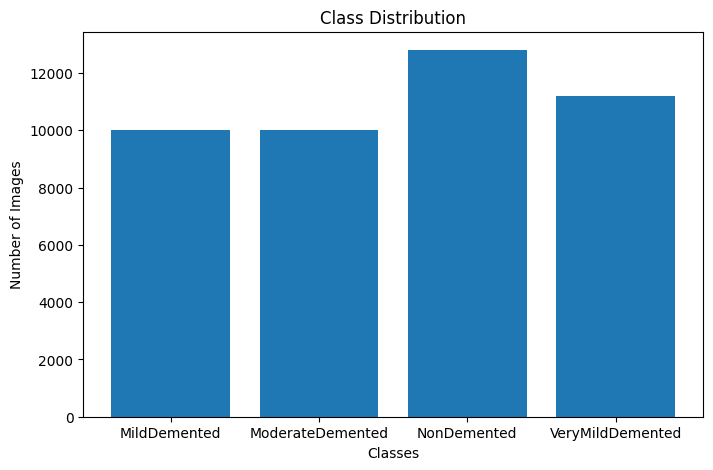

In [6]:
plt.figure(figsize=(8,5))

plt.bar(image_count.keys(), image_count.values())

plt.title("Class Distribution")

plt.xlabel("Classes")

plt.ylabel("Number of Images")

plt.show()

In [7]:
extensions = Counter()

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    for img in os.listdir(class_path):

        ext = os.path.splitext(img)[1].lower()

        extensions[ext]+=1

print(extensions)

Counter({'.jpg': 44000})


In [8]:
sizes = Counter()

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    for img in os.listdir(class_path):

        image = Image.open(os.path.join(class_path,img))

        sizes[image.size]+=1

print(sizes)

Counter({(200, 190): 31107, (180, 180): 6447, (176, 208): 6446})


In [9]:
sample = Image.open(
    os.path.join(dataset_path,
                 classes[0],
                 os.listdir(os.path.join(dataset_path,classes[0]))[0])
)

print(sample.mode)

RGB


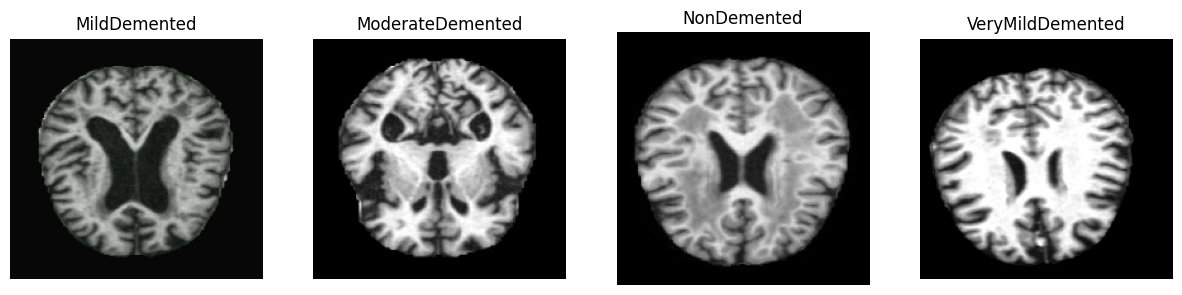

In [11]:
fig, axes = plt.subplots(1,4, figsize=(15,5))

for i,cls in enumerate(classes):

    img_name = os.listdir(os.path.join(dataset_path,cls))[0]

    img_path = os.path.join(dataset_path,cls,img_name)

    img = Image.open(img_path)

    axes[i].imshow(img,cmap="gray")

    axes[i].set_title(cls)

    axes[i].axis("off")

plt.show()

In [12]:
bad_images = []

for cls in classes:

    class_path = os.path.join(dataset_path,cls)

    for img in os.listdir(class_path):

        path = os.path.join(class_path,img)

        try:
            Image.open(path).verify()

        except:
            bad_images.append(path)

print("Corrupted Images :",len(bad_images))

Corrupted Images : 0


In [13]:
import numpy as np

widths = []
heights = []

for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    for img in os.listdir(class_path):
        image = Image.open(os.path.join(class_path, img))
        w, h = image.size

        widths.append(w)
        heights.append(h)

print("Minimum Width :", min(widths))
print("Maximum Width :", max(widths))
print("Minimum Height:", min(heights))
print("Maximum Height:", max(heights))

print("Average Width :", np.mean(widths))
print("Average Height:", np.mean(heights))

Minimum Width : 176
Maximum Width : 200
Minimum Height: 180
Maximum Height: 208
Average Width : 193.55354545454546
Average Height: 191.17177272727272
